# King County Housing — Exploratory Data Analysis

## Client

**Charles Christensen**, a seller. He wants big returns and is asking three
questions: should he renovate, which neighborhood, and when to sell.

## Data

21,597 sales of 21,420 houses in King County, WA, sold between May 2014 and
May 2015.

The data was pulled from the `eda` schema of the course database and joined
on the fly:

```sql
SELECT d.*, s.date, s.price
FROM eda.king_county_house_details AS d
INNER JOIN eda.king_county_house_sales AS s
        ON d.id = s.house_id
ORDER BY d.id, s.date;
```

The result was exported to `data/king_county_joined.csv`, which is not
tracked by git. Re-run the query above to reproduce it.

## Assumptions

- **Neighborhood** is operationalised as `zipcode`, the only geographic unit
  available in the data.
- **Return** is measured as price per square foot of living space, not
  absolute price, so that house size does not drive the result.
- **Repeat sales are real.** 176 houses were sold more than once. The
  shortest gap between two sales is 61 days and no sale date is duplicated,
  so these are genuine resales, not data-entry errors. All are kept.
- **Timing means seasonality.** The data spans a single year, so any timing
  effect is a within-year seasonal pattern, not a multi-year trend.

In [14]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

In [2]:
df = pd.read_csv("data/king_county_joined.csv")
df.shape

(21597, 21)

In [3]:
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
0,1000102,6.000,3.000,2400.000,9373.000,2.000,NaN,0.000,3,7,...,0.000,1991,0.000,98002,47.326,-122.214,2060.000,7316.000,2014-09-16,280000.000
1,1000102,6.000,3.000,2400.000,9373.000,2.000,NaN,0.000,3,7,...,0.000,1991,0.000,98002,47.326,-122.214,2060.000,7316.000,2015-04-22,300000.000
2,1200019,4.000,1.750,2060.000,26036.000,1.000,NaN,0.000,4,8,...,900.000,1947,0.000,98166,47.444,-122.351,2590.000,21891.000,2014-05-08,647500.000
3,1200021,3.000,1.000,1460.000,43000.000,1.000,0.000,0.000,3,7,...,0.000,1952,0.000,98166,47.443,-122.347,2250.000,20023.000,2014-08-11,400000.000
4,2800031,3.000,1.000,1430.000,7599.000,1.500,0.000,0.000,4,6,...,420.000,1930,0.000,98168,47.478,-122.265,1290.000,10320.000,2015-04-01,235000.000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   bedrooms       21597 non-null  float64
 2   bathrooms      21597 non-null  float64
 3   sqft_living    21597 non-null  float64
 4   sqft_lot       21597 non-null  float64
 5   floors         21597 non-null  float64
 6   waterfront     19206 non-null  float64
 7   view           21534 non-null  float64
 8   condition      21597 non-null  int64  
 9   grade          21597 non-null  int64  
 10  sqft_above     21597 non-null  float64
 11  sqft_basement  21145 non-null  float64
 12  yr_built       21597 non-null  int64  
 13  yr_renovated   17749 non-null  float64
 14  zipcode        21597 non-null  int64  
 15  lat            21597 non-null  float64
 16  long           21597 non-null  float64
 17  sqft_living15  21597 non-null  float64
 18  sqft_lot15     21

In [5]:
df.describe()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,price
count,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,21597.000,21597.000,21597.000,21145.000,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000
mean,4580474287.771,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,3.410,7.658,1788.597,291.857,1971.000,836.651,98077.952,47.560,-122.214,1986.620,12758.284,540296.574
std,2876735715.748,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,0.651,1.173,827.760,442.491,29.375,4000.111,53.513,0.139,0.141,685.230,27274.442,367368.140
min,1000102.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,1.000,3.000,370.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000,78000.000
25%,2123049175.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,3.000,7.000,1190.000,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000,322000.000
50%,3904930410.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,3.000,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000,450000.000
75%,7308900490.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,4.000,8.000,2210.000,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000,645000.000
max,9900000190.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,5.000,13.000,9410.000,4820.000,2015.000,20150.000,98199.000,47.778,-121.315,6210.000,871200.000,7700000.000


### First look — observations

**Shape.** 21,597 rows × 21 columns.

**Missing values.** Four columns are incomplete:

| Column | Non-null | Missing |
| --- | --- | --- |
| `waterfront` | 19,206 | 2,391 |
| `view` | 21,534 | 63 |
| `sqft_basement` | 21,145 | 452 |
| `yr_renovated` | 17,749 | 3,848 |

Every other column is complete.

**`date` is a string, not a date.** It has to be converted before any month or
season can be extracted.

**A 33-bedroom house.** `bedrooms` has a mean of 3.37 and a 75th percentile of
4, but a maximum of 33. Either a genuine mansion or a typo for 3 — needs to be
checked against its `sqft_living`.

**Heavily right-skewed columns.** `sqft_lot` has a median of 7,618 and a
maximum of 1,651,359, roughly 200× the typical lot. `price` shows the same
pattern: mean 540,297 against a median of 450,000. Wherever the mean sits well
above the median, a few very large values are stretching the right tail, so
this analysis reports **medians**, not means.

**`yr_renovated` mixes two things.** Its mean is 836.65, which is not a year at
all — it comes from averaging a column that is mostly 0 with a minority of
four-digit years. The 75th percentile is 0, so more than three quarters of the
houses were never renovated. The column is really a flag plus a date, and will
be split into both.

**Waterfront is rare.** The mean of `waterfront` is 0.008, i.e. under 1% of
sales, roughly 150 houses. Too small a group to carry the neighborhood
hypothesis on its own, so `zipcode` and coordinates will do most of that work.

In [6]:
df[df["bedrooms"] > 10]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
4297,1773100755,11.000,3.000,3000.000,4960.000,2.000,0.000,0.000,3,7,...,600.000,1918,19990.000,98106,47.556,-122.363,1420.000,4960.000,2014-08-21,520000.000
6071,2402100895,33.000,1.750,1620.000,6000.000,1.000,0.000,0.000,5,7,...,580.000,1947,0.000,98103,47.688,-122.331,1330.000,4700.000,2014-06-25,640000.000


In [7]:
df[df["yr_renovated"] > 2015]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price
5,3600057,4.000,2.000,1650.000,3504.000,1.000,0.000,0.000,3,7,...,890.000,1951,20130.000,98144,47.580,-122.294,1480.000,3504.000,2015-03-19,402500.000
18,9000025,2.000,1.000,1420.000,4635.000,2.000,0.000,0.000,4,7,...,0.000,1941,19730.000,98115,47.680,-122.304,1810.000,4635.000,2014-12-03,496000.000
50,31000165,5.000,3.500,3620.000,7821.000,2.000,0.000,2.000,3,10,...,830.000,1958,20100.000,98040,47.574,-122.215,2690.000,9757.000,2014-09-11,1490000.000
72,46100204,5.000,3.000,3300.000,33474.000,1.000,NaN,3.000,3,9,...,1430.000,1957,19910.000,98040,47.567,-122.210,3836.000,20953.000,2015-02-21,1510000.000
74,46100504,4.000,3.750,4100.000,22798.000,1.500,NaN,3.000,5,11,...,1560.000,1934,19790.000,98040,47.565,-122.210,3880.000,18730.000,2014-06-17,2030000.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21462,9826701345,3.000,2.500,1620.000,2640.000,2.000,0.000,0.000,4,7,...,0.000,1900,19930.000,98122,47.604,-122.305,1370.000,3840.000,2014-07-15,498000.000
21476,9828200746,2.000,1.500,1120.000,1024.000,2.000,0.000,0.000,3,8,...,0.000,1970,19980.000,98122,47.617,-122.298,1120.000,1549.000,2015-05-04,440000.000
21492,9828700200,4.000,3.000,2170.000,4000.000,2.000,0.000,0.000,4,9,...,560.000,1982,20110.000,98112,47.620,-122.292,1670.000,4000.000,2014-05-05,831000.000
21505,9828701690,3.000,2.000,1530.000,3400.000,1.000,0.000,0.000,3,7,...,540.000,1907,20140.000,98112,47.620,-122.296,1880.000,4212.000,2014-08-06,529000.000


In [8]:
df[(df["yr_built"] < 1900) | (df["yr_built"] > 2015)]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price


In [9]:
df[(df["yr_renovated"] > 0) & (df["yr_renovated"] <= 2015)]

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price


In [10]:
renovated = df[df["yr_renovated"] > 2015]
(renovated["yr_renovated"] % 10 == 0).sum()

np.int64(744)

### Data quality checks

**A 33-bedroom house is not trustworthy.** One house lists 33 bedrooms in
1,620 sqft on a single floor with 1.75 bathrooms — about 49 sqft per bedroom,
which is not a house. A typo for 3 is plausible, but with a single row and no
corroborating pattern there is no evidence for any particular correction, so
`bedrooms` is set to missing for this row rather than guessed. The rest of the
row (price, date, zipcode, size) is sound and is kept. `bedrooms` is not used
in any of the three hypotheses, so this choice does not affect the results.

**An 11-bedroom house is real.** 3,000 sqft over two floors with 3 bathrooms,
built in 1918 — roughly 272 sqft per room. Tight but plausible for a
century-old rooming house. Kept as a genuine outlier.

**`yr_renovated` is systematically multiplied by 10.** 744 rows hold five-digit
values such as 20130 or 19730. Two checks confirm this is systematic, not a
handful of typos:

- No row has a `yr_renovated` between 1 and 2015, so there are no valid
  four-digit values anywhere in the column.
- All 744 non-zero values are divisible by 10.

The whole column is therefore the real year × 10, and is divided by 10 during
cleaning. This leaves 744 renovated houses, about 4% of the houses whose
renovation status is known — a small but workable comparison group for
hypothesis 3.

**`yr_built` is clean.** No row falls outside 1900–2015.

### Research questions and hypotheses

| Question | Hypothesis | Indicators |
| --- | --- | --- |
| Does the time of year affect the sale price? | Houses sold in spring sell for more than houses sold in winter. | month of `date`, median `price` |
| Which neighborhoods deliver the highest returns? | Neighborhoods near the water and near the city centre have a higher price per square foot than outlying neighborhoods. | `zipcode`, `lat`, `long`, `price` / `sqft_living` |
| Does renovating before selling pay off? | Homes renovated recently sell for more than comparable non-renovated homes, while homes renovated long ago show no such premium. | `yr_renovated`, controlled for `grade` and `sqft_living` |

## Cleaning — step A: proven errors

In [18]:
df_clean = df.copy()

# date arrives from the CSV as a string
df_clean["date"] = pd.to_datetime(df_clean["date"])

# yr_renovated is systematically stored as the real year x 10
df_clean.loc[df_clean["yr_renovated"] > 0, "yr_renovated"] = (
    df_clean["yr_renovated"] / 10
)

# 33 bedrooms in 1620 sqft is not credible, and no correction is provable
df_clean.loc[df_clean["bedrooms"] == 33, "bedrooms"] = np.nan

# these four are conceptually whole numbers; they only became floats because
# a NumPy integer column cannot hold missing values. pandas' nullable Int64 can.
for col in ["yr_renovated", "bedrooms", "waterfront", "view"]:
    df_clean[col] = df_clean[col].astype("Int64")

In [19]:
print("date dtype      :", df_clean["date"].dtype)
print("yr_renovated max:", df_clean["yr_renovated"].max())
print("bedrooms max    :", df_clean["bedrooms"].max())
print("waterfront max  :", df_clean["waterfront"].max())
print("view max        :", df_clean["view"].max())
print("rows            :", len(df_clean), "of", len(df))

date dtype      : datetime64[us]
yr_renovated max: 2015
bedrooms max    : 11
waterfront max  : 1
view max        : 4
rows            : 21597 of 21597


### Cleaning summary

No rows were removed — 21,597 in, 21,597 out. Outliers were kept because every
figure here is a median, which they do not affect. Missing values were not
imputed: the affected columns are either unused, or kept as an explicit
`unknown` group.

## Feature engineering

Three of the columns needed to test the hypotheses do not exist in the raw
data and are derived here.

In [20]:
# hypothesis 2: value of a location, independent of house size
df_clean["price_per_sqft"] = df_clean["price"] / df_clean["sqft_living"]

# hypothesis 1: month and season of sale
df_clean["month"] = df_clean["date"].dt.month

season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn",
}
df_clean["season"] = df_clean["month"].map(season_map)

# hypothesis 3: split yr_renovated into a flag and a recency band
def renovation_group(year):
    if pd.isna(year):
        return "unknown"
    if year == 0:
        return "never"
    if year >= 2005:
        return "recent"
    return "old"

df_clean["reno_group"] = df_clean["yr_renovated"].apply(renovation_group)

# age of the house at the moment it was sold
df_clean["house_age"] = df_clean["date"].dt.year - df_clean["yr_built"]

In [21]:
print(df_clean["season"].value_counts(), "\n")
print(df_clean["reno_group"].value_counts(), "\n")
print(df_clean[["price_per_sqft", "house_age"]].describe())

season
spring    6518
summer    6328
autumn    5056
winter    3695
Name: count, dtype: int64 

reno_group
never      17005
unknown     3848
old          479
recent       265
Name: count, dtype: int64 

       price_per_sqft  house_age
count       21597.000  21597.000
mean          264.143     43.323
std           110.000     29.377
min            87.588     -1.000
25%           182.292     18.000
50%           244.645     40.000
75%           318.333     63.000
max           810.139    115.000


### Notes on the derived columns

**Spring is over-represented by construction, not by market activity.** The
data window runs from May 2014 to May 2015, so spring months appear four times
(May 2014 plus March–May 2015) while every other season appears three times.
That alone explains most of the gap between 6,518 spring sales and 3,695
winter sales. Hypothesis 1 is therefore tested on **median price by month**,
never on sale counts, since a median is not affected by how many rows fall in
a bucket.

**The renovated groups are small.** Of 21,597 sales, 17,005 were never
renovated, 3,848 have an unknown renovation status, 479 were renovated before
2005 and only 265 from 2005 onwards. 265 is enough for a median comparison but
small enough that the sample size must be stated alongside any claim.

**Assumption: "recent" means 2005 or later.** The cut-off is ten years before
the end of the data window. It is a choice, not a fact, and a different
boundary would shift the group sizes.

**Some houses sold before they were built.** `house_age` has a minimum of -1,
i.e. a sale in 2014 of a house recorded as built in 2015. Off-plan sales of
properties under construction are normal, so these rows are kept.

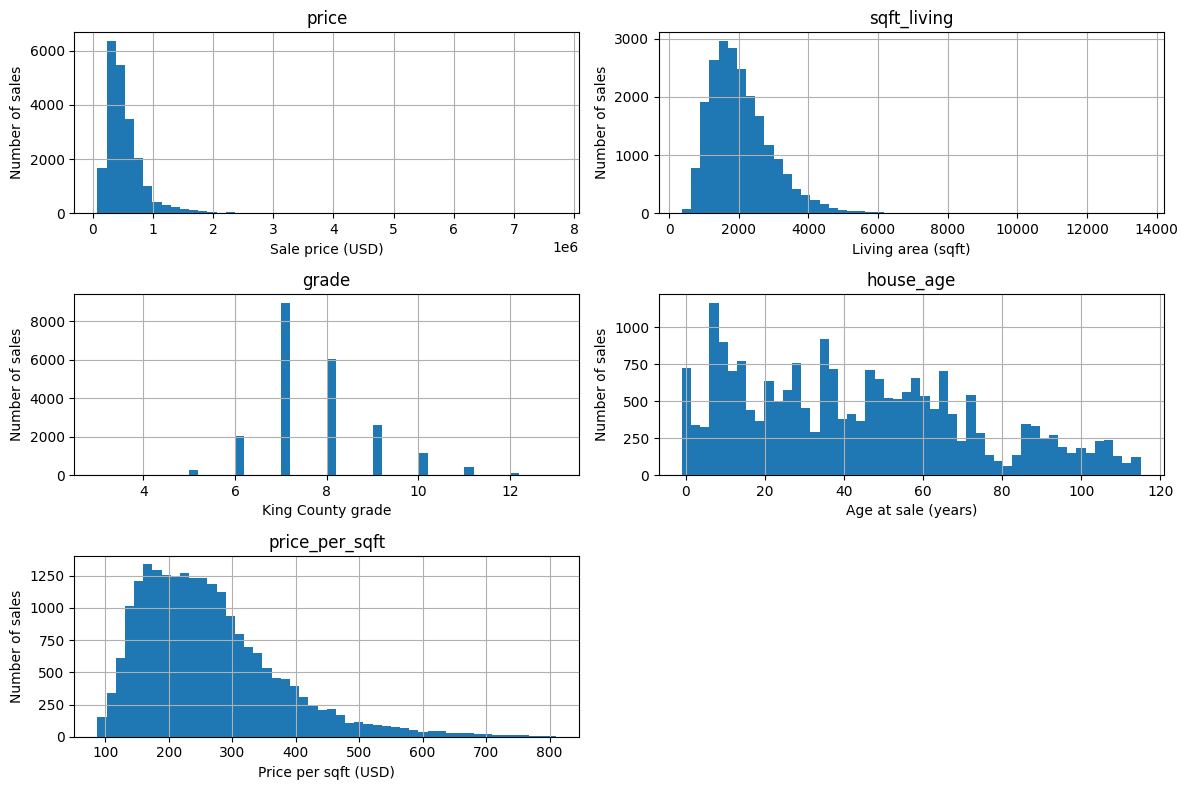

In [23]:
cols = ["price", "sqft_living", "grade", "house_age", "price_per_sqft"]
labels = {
    "price": "Sale price (USD)",
    "sqft_living": "Living area (sqft)",
    "grade": "King County grade",
    "house_age": "Age at sale (years)",
    "price_per_sqft": "Price per sqft (USD)",
}

axes = df_clean[cols].hist(figsize=(12, 8), bins=50)

for ax in axes.flatten():
    name = ax.get_title()
    if name:
        ax.set_xlabel(labels[name])
        ax.set_ylabel("Number of sales")

plt.tight_layout()
plt.show()

Price, living area and price per sqft are all right-skewed, so medians are used
throughout. Grade is concentrated on 7 and 8. House age peaks around 10 years,
with a second broader peak around 35–40.

## Hypothesis 1 — Do houses sell for more in spring?

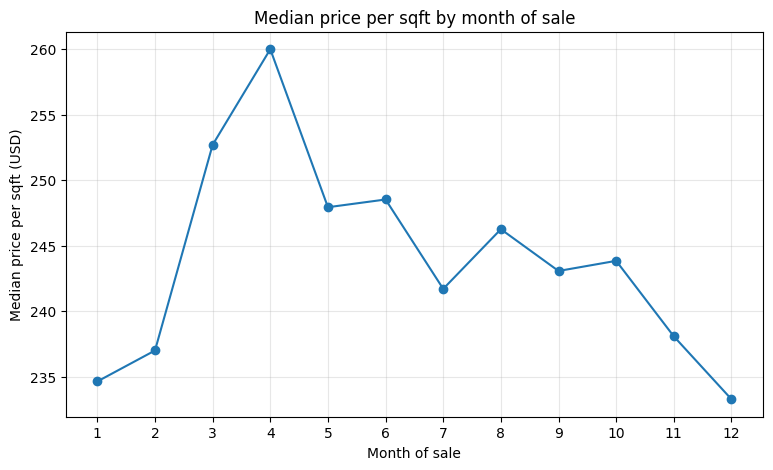

month
1    234.700
2    237.000
3    252.700
4    260.000
5    247.900
6    248.500
7    241.700
8    246.300
9    243.100
10   243.900
11   238.100
12   233.300
Name: price_per_sqft, dtype: float64


In [24]:
monthly = df_clean.groupby("month")["price_per_sqft"].median()

plt.figure(figsize=(9, 5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.xlabel("Month of sale")
plt.ylabel("Median price per sqft (USD)")
plt.title("Median price per sqft by month of sale")
plt.xticks(range(1, 13))
plt.grid(alpha=0.3)
plt.show()

print(monthly.round(1))

**Hypothesis 1 is supported.** Median price per sqft peaks in April at $260 and
bottoms out in December at $233 — an 11% swing. Averaged across the three
spring months ($253) against the three winter months ($235), spring sells for
about 8% more per square foot. The pattern is smooth rather than jagged, which
suggests a real seasonal cycle rather than noise.

## Hypothesis 2 — Which neighborhoods deliver the highest price per sqft?

In [25]:
by_zip = (
    df_clean.groupby("zipcode")["price_per_sqft"]
    .median()
    .sort_values(ascending=False)
)

print("Top 10 zipcodes\n", by_zip.head(10).round(1), "\n")
print("Bottom 10 zipcodes\n", by_zip.tail(10).round(1), "\n")
print("ratio top10 / bottom10:", round(by_zip.head(10).mean() / by_zip.tail(10).mean(), 2))

Top 10 zipcodes
 zipcode
98039   565.200
98004   456.900
98109   427.700
98112   424.200
98119   416.700
98102   406.400
98105   391.800
98040   376.400
98107   372.800
98103   360.500
Name: price_per_sqft, dtype: float64 

Bottom 10 zipcodes
 zipcode
98188   163.900
98042   159.200
98031   157.100
98003   154.800
98030   152.200
98092   149.200
98002   147.200
98001   147.100
98032   146.200
98023   145.000
Name: price_per_sqft, dtype: float64 

ratio top10 / bottom10: 2.76


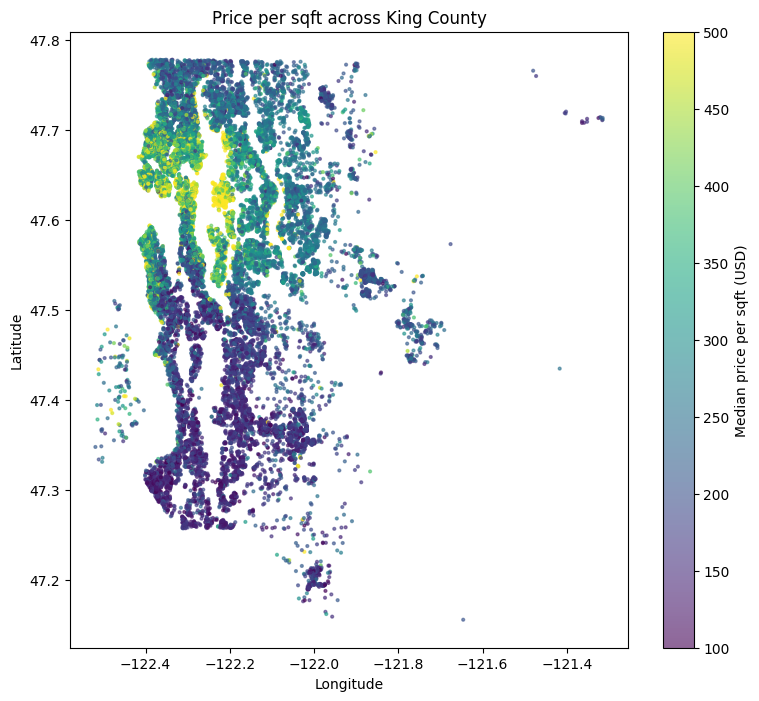

In [26]:
plt.figure(figsize=(9, 8))
sc = plt.scatter(
    df_clean["long"],
    df_clean["lat"],
    c=df_clean["price_per_sqft"],
    cmap="viridis",
    s=4,
    alpha=0.6,
    vmin=100,
    vmax=500,
)
plt.colorbar(sc, label="Median price per sqft (USD)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Price per sqft across King County")
plt.show()

**Hypothesis 2 is supported, and more strongly than expected.** The ten highest
zipcodes average 2.76x the price per sqft of the ten lowest — the hypothesis
predicted at least 2x. Medina (98039) leads at $565/sqft, against $145/sqft in
Federal Way (98023), a fourfold gap between the single best and worst zipcode.

The map shows this is not scattered: high values cluster tightly around Lake
Washington and central Seattle, while the low-value zipcodes sit together in
the southern suburbs. Location, not house size, is what price per square foot
is measuring here.

## Hypothesis 3 — Does renovating before selling pay off?

Renovated homes are older on average, so a plain comparison would measure age,
not renovation. The comparison below is made within each grade band, so only
houses of similar build quality are compared with each other.

In [27]:
known = df_clean[df_clean["reno_group"] != "unknown"]
order = ["never", "old", "recent"]

medians = known.pivot_table(
    index="grade", columns="reno_group", values="price_per_sqft", aggfunc="median"
).reindex(columns=order).loc[6:10]

counts = known.pivot_table(
    index="grade", columns="reno_group", values="price", aggfunc="count"
).reindex(columns=order).loc[6:10]

print("Median price per sqft\n", medians.round(1), "\n")
print("Number of sales\n", counts)

Median price per sqft
 reno_group   never     old  recent
grade                             
6          244.200 199.100 219.300
7          226.000 263.700 290.500
8          244.400 314.700 335.800
9          251.700 349.300 351.400
10         268.300 423.400 479.200 

Number of sales
 reno_group    never     old  recent
grade                              
6          1604.000  49.000  24.000
7          7087.000 189.000  87.000
8          4766.000 138.000  82.000
9          2065.000  61.000  50.000
10          893.000  23.000  18.000


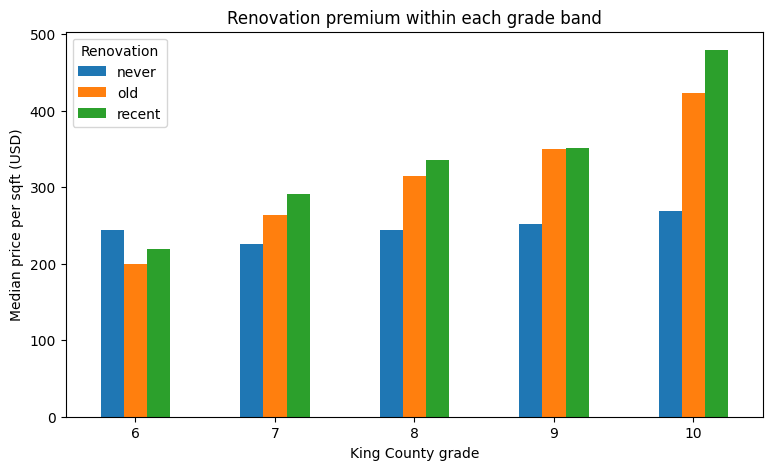

In [28]:
medians.plot(kind="bar", figsize=(9, 5))
plt.xlabel("King County grade")
plt.ylabel("Median price per sqft (USD)")
plt.title("Renovation premium within each grade band")
plt.legend(title="Renovation")
plt.xticks(rotation=0)
plt.show()

In [29]:
known2 = known.copy()
known2["renovated"] = known2["reno_group"] != "never"

g78 = known2[known2["grade"].isin([7, 8])]

per_zip = g78.pivot_table(
    index="zipcode", columns="renovated", values="price_per_sqft", aggfunc="median"
)
per_zip.columns = ["never", "renovated"]
per_zip = per_zip.dropna()
per_zip["premium_pct"] = (per_zip["renovated"] / per_zip["never"] - 1) * 100

print(per_zip["premium_pct"].describe().round(1))
print("\nzipcodes where renovated sells higher:",
      (per_zip["premium_pct"] > 0).sum(), "of", len(per_zip))

count    68.000
mean      4.600
std      17.600
min     -33.900
25%      -5.100
50%       2.700
75%      14.400
max      48.900
Name: premium_pct, dtype: float64

zipcodes where renovated sells higher: 39 of 68


**Hypothesis 3 is not supported once location is controlled for.**

Comparing renovated against never-renovated homes within each grade band, the
premium looks large: +29% at grade 7 rising to +79% at grade 10. Recency adds
little — renovations from before 2005 carry almost the same premium as recent
ones, so the second half of the hypothesis was wrong from the start.

But grade controls for build quality, not for where the house is. Repeating the
comparison **within each zipcode**, restricted to grades 7 and 8, the premium
collapses: a median of +2.7% across 68 zipcodes, ranging from -34% to +49%, and
positive in only 39 of 68 — barely better than a coin flip.

Most of the apparent renovation premium was a neighborhood effect. Renovated
homes cluster in expensive zipcodes, and the first comparison was picking that
up rather than the value of the renovation itself.

For Charles this matters: renovating is not a reliable way to raise the sale
price. Timing and location are the levers the data actually supports.

## Insights

**1. Timing moves the price by about 10%.** Median price per square foot peaks
in April at $260 and bottoms out in December at $233. Averaged by season,
spring sells about 8% above winter. The curve is smooth rather than jagged,
which points to a real seasonal cycle rather than noise.

**2. Location is the single biggest lever (geographic insight).** The ten
highest zipcodes command 2.76x the price per square foot of the ten lowest.
Medina (98039) reaches $565/sqft while Federal Way (98023) sits at $145/sqft.
Mapped by coordinates, the expensive zipcodes form one tight cluster around
Lake Washington and central Seattle, and the cheap ones form a second cluster
in the southern suburbs. Nothing else in this dataset separates prices as
sharply.

**3. The renovation premium is mostly a neighborhood effect.** Compared within
grade bands, renovated homes look 29–79% more valuable per square foot.
Compared within the same zipcode, that premium collapses to a median of +2.7%
and is positive in only 39 of 68 zipcodes. Renovated homes are concentrated in
expensive areas, and the first comparison was measuring the area.

**4. One column was systematically corrupted.** `yr_renovated` stored every
renovation year multiplied by ten. All 744 non-zero values were affected and no
valid four-digit value existed anywhere in the column. Left uncorrected, every
renovation result would have been meaningless.

## Recommendations for Charles

**1. List in early spring and aim to close in April.** On the same house this is
worth roughly 10% against a December sale — the cheapest return available,
since it costs nothing but patience. Avoid closing between November and
January.

**2. Judge any property by its zipcode first.** Price per square foot is set
far more by where a house sits than by anything that can be changed about the
house. When deciding what to hold, sell or acquire, the north-west cluster
around Lake Washington and central Seattle carries roughly three times the
value density of the southern suburbs.

**3. Do not renovate as a price play.** Once neighborhood is held constant,
renovation shows no reliable return — barely better than a coin flip across
zipcodes. Renovate for saleability or because the house needs it, not as an
investment in the sale price.

## Limitations

The data covers a single year, May 2014 to May 2015, so the seasonal pattern is
observable but no multi-year trend can be claimed. All findings are
associations, not causes: this analysis can show that renovated homes sell
higher, not that renovating caused it. The renovation comparison rests on 744
renovated sales, and the within-zipcode test on grades 7 and 8 only, so
individual zipcode figures carry wide uncertainty.